# Quickstart

Run the reference week, look at what the naive household does to the feeder, and
score your own idea.

Everything below takes about a minute end to end.

In [1]:
import jax
import jax.numpy as jnp

from sandbox.scenarios import reference_scenario, end_of_line_impedance_ohm
from sandbox.controller import base_controller, passive_controller
from sandbox.rollout import rollout, build_env
from sandbox.metrics import score, compare

population = reference_scenario()
env = build_env(population)

print(f"{population.num_pq} connection points, {population.num_agents} of them agents")
print(f"end-of-line impedance: {end_of_line_impedance_ohm():.3f} ohm")
for name in ("tenant", "pv_only", "pv_battery", "large_flex"):
    print(f"  {name:<12} {population.type_of_pq.count(name)}")

18 connection points, 12 of them agents
end-of-line impedance: 0.135 ohm
  tenant       6
  pv_only      5
  pv_battery   5
  large_flex   2


## The pathology

`passive` never touches the battery. `self_consumption` is what every home
battery ships with. Watch the **ramp** column.

In [2]:
scores = {}
for controller in (passive_controller(), base_controller()):
    trajectory = rollout(controller, population, jax.random.PRNGKey(0), env=env)
    scores[controller.name] = score(trajectory, population)

print(compare(scores))

                   export_pk_kW   draw_pk_kW      reverse      coincid      ramp_kW         corr         loss      curtail     selfcons          CHF        >1.05
-----------------------------------------------------------------------------------------------------------------------------------------------------------------
passive                    46.6         15.9          44%        0.595          6.8        +0.13        0.47%         0.0%          21%           68        0.00%
self_consumption           44.2          9.7          42%        0.571         11.8        +0.07        0.41%         0.0%          37%           91        0.00%


Self-consumption is better for the household on every count it can see — and
makes the steepest swing at the transformer roughly **74% worse**. Every battery
fills at the same moment, so every battery stops absorbing at the same moment.

No price is involved. The correlation is in the weather and the working day.

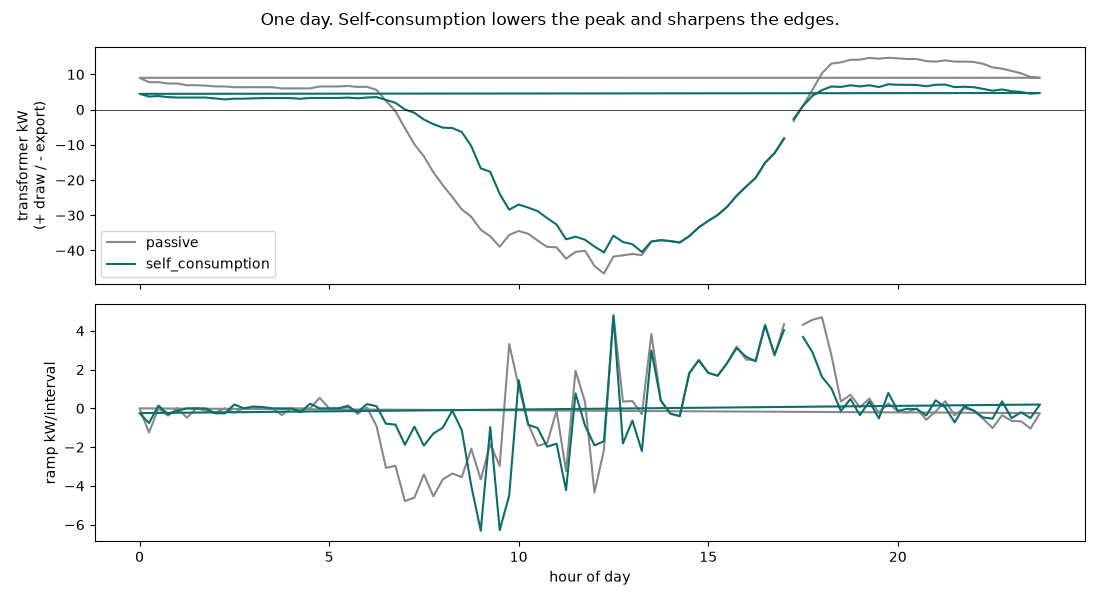

In [3]:
import matplotlib.pyplot as plt
from sandbox.export import feeder_dataframe

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for controller, colour in ((passive_controller(), "#888"), (base_controller(), "#0b6e6b")):
    trajectory = rollout(controller, population, jax.random.PRNGKey(0), env=env)
    feeder = feeder_dataframe(trajectory).query("day == 2")
    axes[0].plot(feeder.hour, feeder.transformer_kw, color=colour, label=controller.name)
    axes[1].plot(feeder.hour[1:], feeder.transformer_kw.diff()[1:], color=colour)

axes[0].set_ylabel("transformer kW\n(+ draw / - export)"); axes[0].legend(); axes[0].axhline(0, lw=0.5, color="k")
axes[1].set_ylabel("ramp kW/interval"); axes[1].set_xlabel("hour of day")
fig.suptitle("One day. Self-consumption lowers the peak and sharpens the edges.")
plt.tight_layout()

## What one household can see

No price anywhere in it. Voltage is the congestion signal, and it is the one
every household reads at the same instant — which is the whole problem.

In [4]:
from sandbox.observation import to_local

state, timestep = env.reset(jax.random.PRNGKey(0))
local = to_local(env.environment, timestep.observation, state)

for name, values in local.as_dict().items():
    print(f"{name:<22} {jnp.round(values[:4], 2)}")

time_sin               [0.81 0.81 0.81 0.81]
time_cos               [0.58 0.58 0.58 0.58]
voltage_pu             [1. 1. 1. 1.]
meter_kw               [-0.51      -0.22      -4.91       3.1299999]
load_kw                [0.51 0.22 1.37 0.39]
load_forecast_kw       [0.48999998 0.21       1.23       0.28      ]
pv_available_kw        [0. 0. 0. 0.]
soc_kwh                [0.         0.         5.6299996  0.78999996]
soc_headroom_kwh       [ 0.    0.   14.37 12.21]
bat_charge_max_kw      [ 0.  0. 10.  5.]
bat_discharge_max_kw   [ 0.         0.        10.         3.1499999]
p_min_kw               [ -0.  -0. -10.  -5.]
p_max_kw               [ 0.         0.        10.         3.1499999]


## Score your own

Edit `my_controller` in `sandbox/controller.py` and `MyTariff` in
`sandbox/tariff.py`, then run this. Four cells: your tariff and the reference,
against your controller and the reference.

In [5]:
from sandbox.controller import MY_TUNING_GRID, my_controller_bundle
from sandbox.tariff import my_tariff
from sandbox.evaluate import Submission, evaluate

evaluation = evaluate(
    Submission(controller=my_controller_bundle(), tariff=my_tariff, candidates=MY_TUNING_GRID),
    population,
    seeds=4,
)
print(evaluation)

                      export_pk_kW   draw_pk_kW      reverse      coincid      ramp_kW         corr         loss      curtail     selfcons          CHF        >1.05
--------------------------------------------------------------------------------------------------------------------------------------------------------------------
fair_leg/base                 51.9          8.9          42%        0.659         10.4        +0.08        0.44%         0.0%          37%           98        0.00%
fair_leg/submitted            51.9          8.9          42%        0.659         10.4        +0.08        0.44%         0.0%          37%           98        0.00%
submitted/base                31.9          8.9          42%        0.854          7.8        +0.09        0.27%        14.5%          43%           44        0.00%
submitted/submitted           21.3          8.9          42%        0.682          7.4        +0.10        0.16%        24.6%          49%            6        0.00%

revenue a

## Debugging

`fast=False` swaps the scan for a Python loop and the vmap for a list
comprehension. Values become concrete, so `if` and `print` work and the
traceback points at your line. Same answer, ~14x slower.

Or write the whole thing in NumPy — see `sandbox/numpy_bridge.py`.

In [6]:
trajectory = rollout(base_controller(), population, jax.random.PRNGKey(0), n_steps=8, env=env, fast=False)
print("p_set_kw, first interval:", jnp.round(trajectory.p_set_kw[0], 2))

p_set_kw, first interval: [0.72999996 1.18       0.91999996 0.25       0.71       0.77
 0.77       0.19999999 0.81       0.45999998 0.21       0.68      ]


## Out to pandas

No JAX beyond this point — the fairness audit and any visualisation can be done
entirely in tools you already know. All eighteen connection points are here,
tenants included; they have no agent and are missing from anything indexed by
one.

In [7]:
from sandbox.export import to_dataframe

trajectory = rollout(base_controller(), population, jax.random.PRNGKey(0), env=env)
frame = to_dataframe(trajectory, population, label="self_consumption")

frame.groupby("household").agg(
    settlement_chf=("settlement_chf", "sum"),
    mean_meter_kw=("meter_kw", "mean"),
    peak_voltage_pu=("voltage_pu", "max"),
).round(2)

,settlement_chf,mean_meter_kw,peak_voltage_pu
household,,,
large_flex,15.020000,0.38,1.01
pv_battery,103.099998,0.91,1.01
pv_only,52.419998,0.60,1.01
tenant,-79.830002,-0.35,1.01
